# Lab 0x02 - Adversarial Attack

此 lab 為 One Pixel Attack 的實作，目標是對產生惡意樣本的方法有更深入的了解

## 1. Setup

Import the necessary packages

In [ ]:
!pip install wget

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import torch
import tqdm
import wget
import zipfile
from torch.nn.functional import softmax
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.models.resnet import resnet18

下載 CIFAR-10 資料集

In [ ]:
if not os.path.exists("cifar10-python"):
    wget.download("https://www.kaggle.com/api/v1/datasets/download/pankrzysiu/cifar10-python", out="cifar10-python.tar.gz")
    zipfile.ZipFile("cifar10-python.tar.gz").extractall("cifar10-python")

預覽資料集

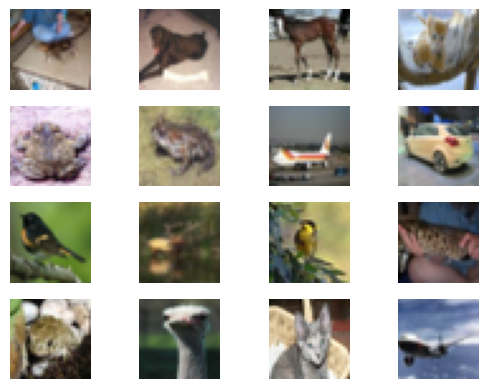

In [18]:
dataset = CIFAR10(root="cifar10-python", train=False, transform=transforms.ToTensor())
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
idx = random.sample(range(len(dataset)), 16)
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(dataset[idx[i]][0].permute(1, 2, 0))
    plt.axis('off')
plt.show()

設定計算位置，因為此 lab 非常簡單，所以使用 CPU 已經足夠，若要使用 GPU，請將 device 改為 'cuda'

In [19]:
device = 'cpu' # 'cuda'

載入預先訓練好的模型作為攻擊目標

In [ ]:
# for colab user, uncomment this
# wget.download("https://raw.githubusercontent.com/unichk/ais3-junior-AI-security/refs/heads/main/lab/0x02-Adversarial-Attack/cifar10_model.pth", out="cifar10_model.pth")
model = resnet18(weights=None, num_classes=10).to(device)
model.load_state_dict(torch.load("cifar10_model.pth", map_location=device))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 2. Attack

攻擊設定

TODO: 嘗試不同設定
1. 不同的初始圖片
2. 嘗試不同的目標 (0-9)，None 為 untargeted
3. 改變攻擊的數量
4. 改變攻擊的次數

In [21]:
base_idx = 7
base_img = dataset[base_idx][0].to(device)
original_label = dataset[base_idx][1]
target_label = None
n = 400
iterations = 100

確定選擇的樣本原本有被分類正確

In [22]:
with torch.no_grad():
    output = model(base_img.unsqueeze(0))
    assert output.argmax(dim=1).item() == original_label, "The model does not predict the original label correctly."

印出攻擊前的圖片資訊

In [23]:
output = softmax(output, dim=1)
if target_label is None:
    print(f'Original probs: {", ".join([f"{int(p * 100):02d}%" for p in output[0]])}')
    print(f"Original label: {labels[original_label]}")
    print(f"Target label: {labels[target_label] if target_label is not None else 'None'}")

Original probs: 00%, 00%, 00%, 04%, 00%, 00%, 94%, 00%, 00%, 00%
Original label: frog
Target label: None


固定 random seed

In [24]:
np.random.seed(1337)

初始化方法

TODO: 更改初始化的方法，例如：uniform, normal

In [25]:
def init(n=400):
    return np.hstack([
        np.random.randint(0, 32, size=(n, 2)),
        np.random.normal(128, 127, size=(n, 3)).clip(0, 255)
    ]).astype(np.float32)

crossover 方法

$x = x1 + 0.5 * (x2 - x3)$

TODO: 嘗試不同的 crossover 方法，包含加入變異

In [26]:
def crossover(x):
    new = np.empty_like(x)
    for i in range(x.shape[0]):
        r1, r2, r3 = np.random.choice(x.shape[0], 3, replace=False)
        new[i] = x[r1] + 0.5 * (x[r2] - x[r3])
    return np.hstack([new[:, :2].clip(0, 31), new[:, 2:].clip(0, 255)]).astype(np.uint8)

評分方法

TODO: 嘗試不同的評分方式

In [27]:
def eval(x):
    adv_img = torch.stack([base_img] * x.shape[0])

    for i in range(x.shape[0]):
        row = int(round(x[i, 0]))
        col = int(round(x[i, 1]))

        adv_img[i, :, row, col] = torch.tensor(
            x[i, 2:],
            dtype=base_img.dtype,
            device=device
        ) / 255.0

    with torch.no_grad():
        output = model(adv_img)

    output = softmax(output, dim=1)

    if target_label is None:
        return -output[:, original_label]
    else:
        return output[:, target_label]

篩選方法

TODO: 嘗試不同的篩選策略

In [28]:
def select(prev, prev_score, x, score):
    win = score > prev_score

    next_population = prev.copy()
    next_population[win.cpu().numpy()] = x[win.cpu().numpy()]

    next_score = prev_score.clone()
    next_score[win] = score[win]

    return next_population, next_score

執行攻擊

In [29]:
prev = init(n)
prev_score = eval(prev)
bar = tqdm.tqdm(range(iterations), desc="Attacking")
for _ in bar:
    x = crossover(prev)
    score = eval(x)
    prev, prev_score = select(prev, prev_score, x, score)
    bar.set_postfix({"best_score": prev_score.max().item(), "mean_score": prev_score.mean().item()})

Attacking: 100%|██████████| 100/100 [00:15<00:00,  6.46it/s, best_score=-0.000187, mean_score=-0.000187]


檢視攻擊成果

Final probs: 00%, 00%, 00%, 72%, 12%, 00%, 00%, 14%, 00%, 00%
Final label: cat
Attack success: True


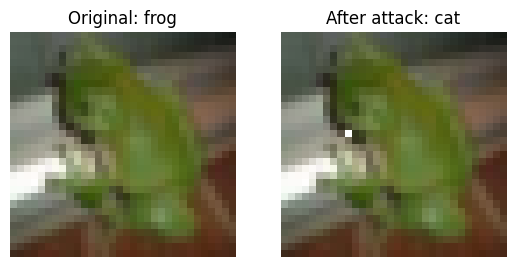

In [30]:
final_adv_img = base_img.clone()
best_attack = prev[prev_score.argmax().item()]
row = int(round(best_attack[0]))
col = int(round(best_attack[1]))

final_adv_img[:, row, col] = torch.tensor(
    best_attack[2:],
    dtype=base_img.dtype,
    device=base_img.device
) / 255.0

with torch.no_grad():
    output = model(final_adv_img.unsqueeze(0))

output = softmax(output, dim=1)
final_label = output.argmax(dim=1).item()

if target_label is None:
    print(
        f'Final probs: {", ".join([f"{int(p * 100):02d}%" for p in output[0]])}\n'
        f"Final label: {labels[final_label]}"
    )
    print(f"Attack success: {final_label != original_label}")
else:
    print(
        f'Final probs: {", ".join([f"{int(p * 100):02d}%" for p in output[0]])}'
        f"Final label: {labels[final_label if final_label is not None else 'None']}"
    )
    print(f"Attack success: {final_label == target_label}")

plt.subplot(1, 2, 1)
plt.imshow(base_img.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Original: {labels[original_label]}")
plt.subplot(1, 2, 2)
plt.imshow(final_adv_img.permute(1, 2, 0))
plt.axis("off")
plt.title(f"After attack: {labels[final_label]}")
plt.show()